## Regression Dataset

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

c:\Users\Youssef Haitham\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("yasserh/loan-default-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Youssef Haitham\.cache\kagglehub\datasets\yasserh\loan-default-dataset\versions\1


In [3]:
datasetname="Loan_Default.csv"
newpath=os.path.join(path,datasetname)
df=pd.read_csv(newpath)
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


## PreProcessing

In [4]:
df.rename(columns={'dtir1': 'Debt_to_Income_Ratio'}, inplace=True)


In [5]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'Debt_to_Income_Ratio'],
      dtype='object')

In [6]:
df=df.drop(columns="ID")
df.shape

(148670, 33)

NULLS

In [7]:
df.isna().sum()

year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_application      200
LTV                 

In [8]:
df.dtypes

year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
age                           object
s

Label Encoding

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))  # convert to string to avoid errors

# df is now fully encoded
df.head()


,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,Debt_to_Income_Ratio
0,2019,0,3,1,0,1,0,0,1,116500,...,3,758,0,0,2,98.728814,3,1,1,45.0
1,2019,0,2,1,1,1,0,0,0,206500,...,2,552,1,3,2,NaN,0,1,1,NaN
2,2019,0,2,2,0,1,0,0,1,406500,...,3,834,0,1,2,80.019685,3,1,0,46.0
3,2019,0,2,1,0,4,0,0,1,456500,...,3,587,0,2,1,69.376900,0,1,0,42.0
4,2019,0,1,2,0,1,0,0,1,696500,...,1,602,1,0,1,91.886544,0,1,0,39.0


Correlation Matrix

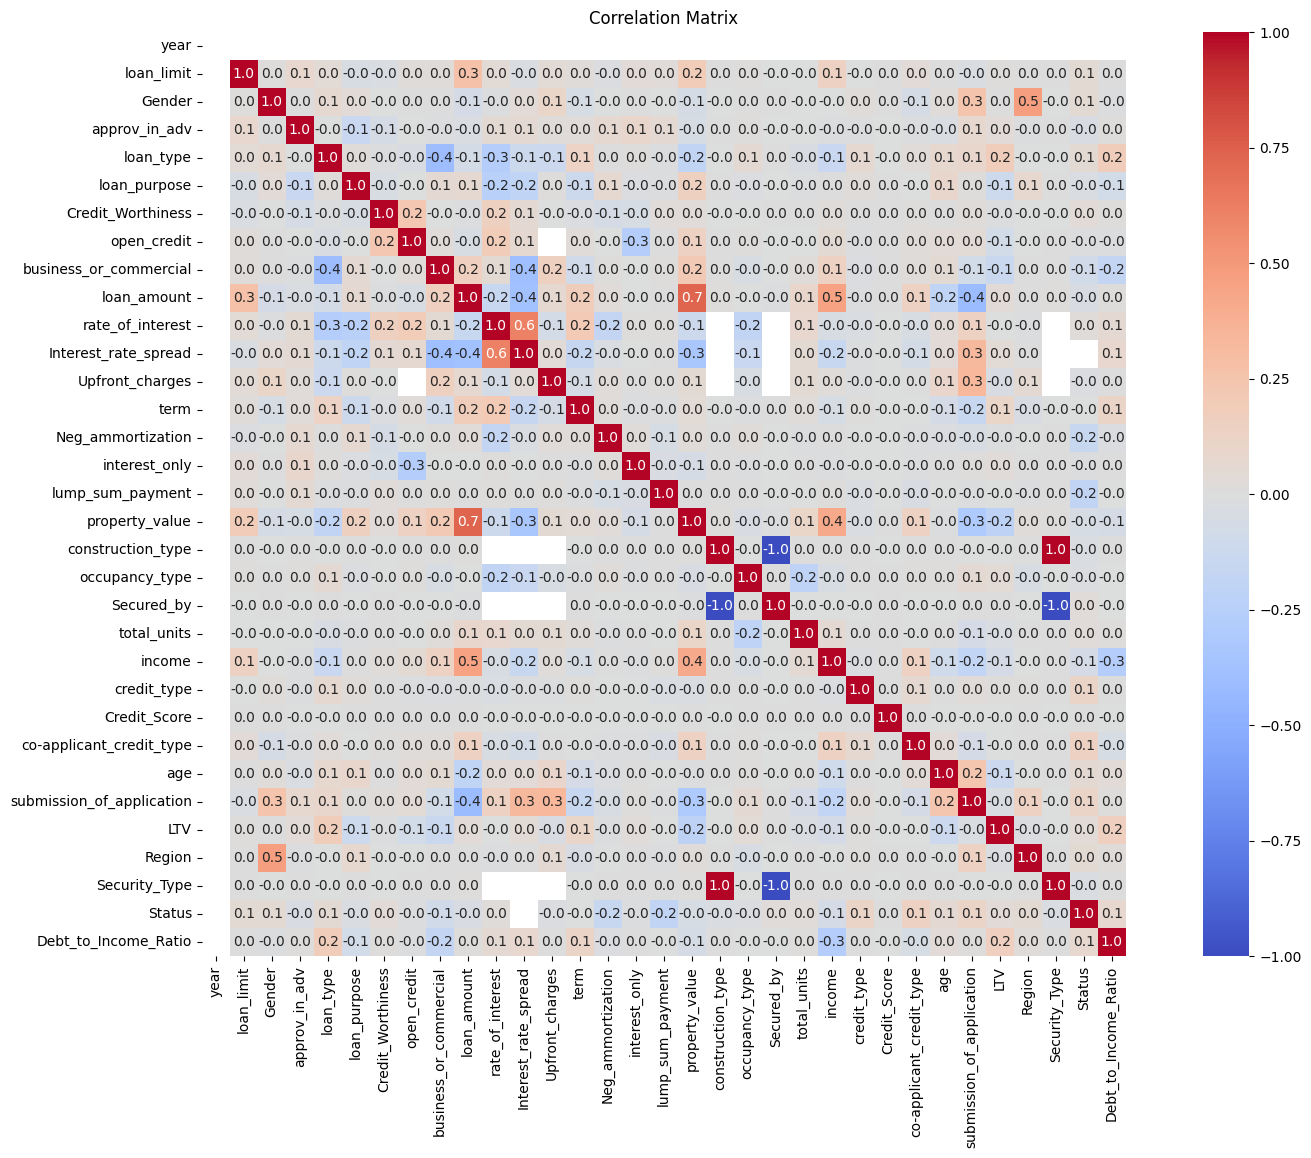

In [10]:
Correlation=df.corr()
plt.figure(figsize=(20,12))
sns.heatmap(Correlation,annot=True,cmap="coolwarm",square=True, fmt=".1f")
plt.title("Correlation Matrix")
plt.show()

In [11]:
df=df.drop(columns="construction_type") #dropping Construction type since it has very high correlation with another feature

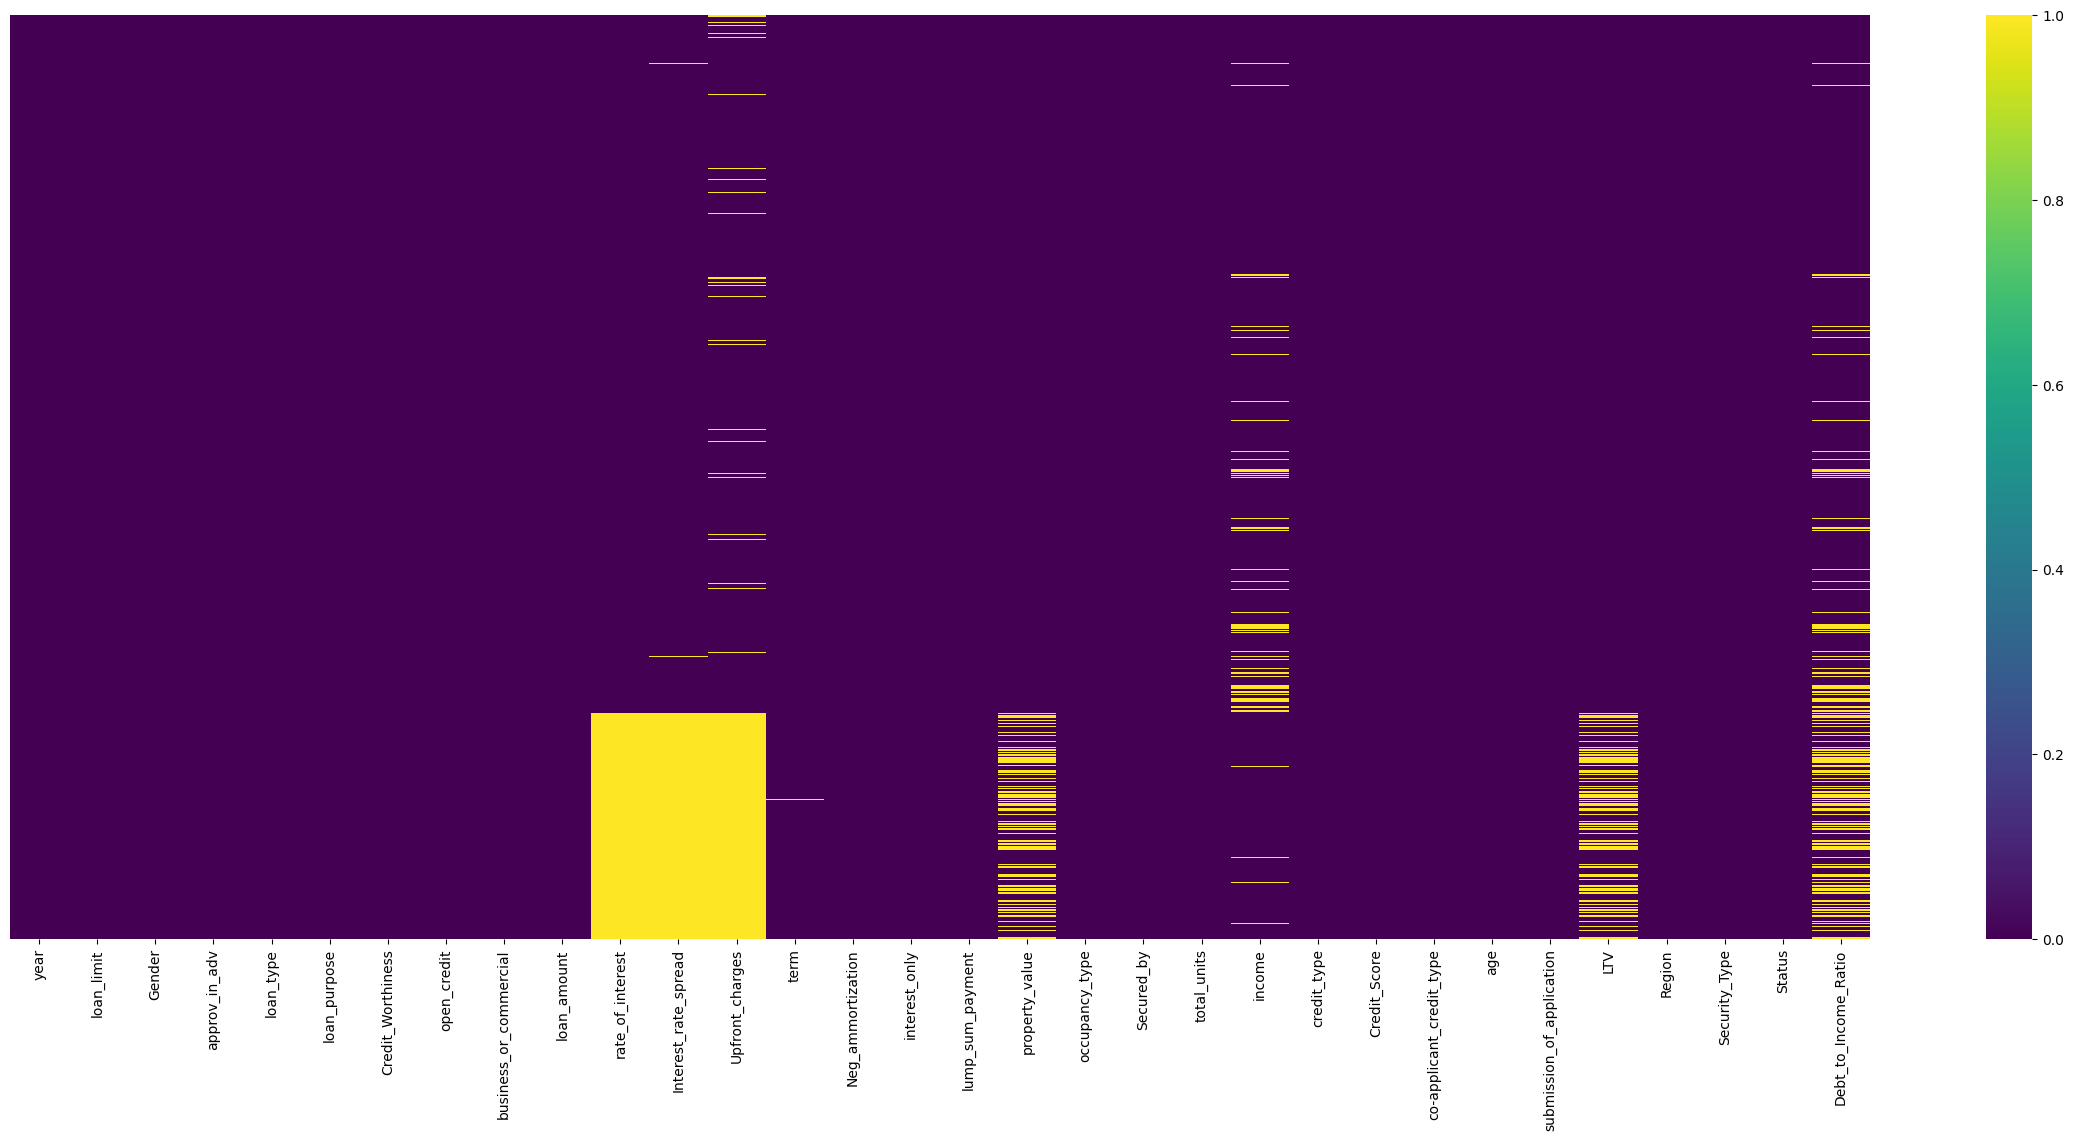

In [12]:
sorted=df.sort_values(by=["rate_of_interest","Interest_rate_spread","Upfront_charges"],ascending=False)
plt.figure(figsize=(30,12))
sns.heatmap(sorted.isnull(),yticklabels=False,cmap='viridis')
plt.show()

In [13]:
df['Debt_to_Income_Ratio'].count()

np.int64(124549)

Dropping nulls in term since they are minimal and a very small ammount and in dtir since that is my target

In [14]:
print(df['term'].isnull().sum(), df['Debt_to_Income_Ratio'].isnull().sum())   
df = df.dropna(subset=['term'])
df = df.dropna(subset=['Debt_to_Income_Ratio'])
print(df['term'].isnull().sum(), df['Debt_to_Income_Ratio'].isnull().sum())   


41 24121
0 0


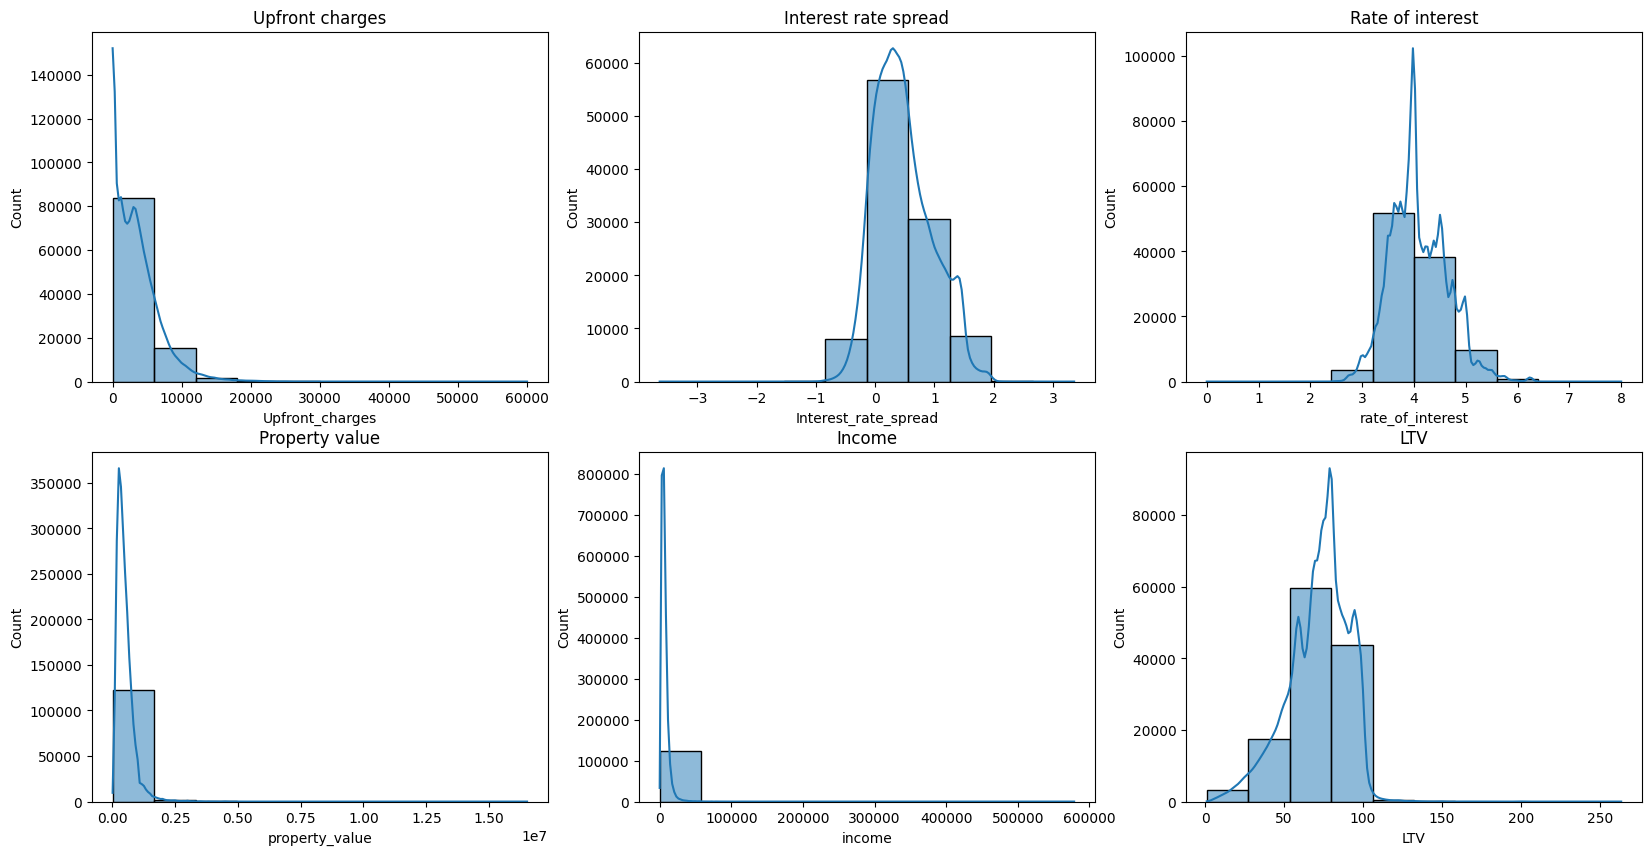

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
s1g1 = sns.histplot(df['Upfront_charges'], bins=10, kde=True, ax=axes[0, 0])
s1g1.set_title('Upfront charges')
s1g2 = sns.histplot(df['Interest_rate_spread'], bins=10, kde=True, ax=axes[0, 1])
s1g2.set_title('Interest rate spread')
s1g3 = sns.histplot(df['rate_of_interest'], bins=10, kde=True, ax=axes[0, 2])
s1g3.set_title('Rate of interest')
s1g4=sns.histplot(df['property_value'], bins=10, kde=True, ax=axes[1, 0])
s1g4.set_title('Property value')
s1g5 = sns.histplot(df['income'], bins=10, kde=True, ax=axes[1, 1])
s1g5.set_title('Income')
s1g6 =sns.histplot(df['LTV'],bins=10,kde=True, ax=axes[1, 2])
s1g6.set_title('LTV')
plt.show()

Filling Nulls
based on these graphs we decided to fill with median since outliers will affect the mean making our data inaccurate

In [16]:
df=df.copy()
nulls_columns = df.columns[df.isnull().any()]
print("Columns with null values:", nulls_columns.tolist())
for col in nulls_columns:
    nulls=df[col].isnull().sum()
    print(f"Column '{col}' has {nulls} null values.")
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
    print(f"Column '{col}'now has {df[col].isnull().sum()} null values after filling with median.")


Columns with null values: ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'property_value', 'income', 'LTV']
Column 'rate_of_interest' has 20326 null values.
Column 'rate_of_interest'now has 0 null values after filling with median.
Column 'Interest_rate_spread' has 20326 null values.
Column 'Interest_rate_spread'now has 0 null values after filling with median.
Column 'Upfront_charges' has 23114 null values.
Column 'Upfront_charges'now has 0 null values after filling with median.
Column 'property_value' has 2 null values.
Column 'property_value'now has 0 null values after filling with median.
Column 'income' has 110 null values.
Column 'income'now has 0 null values after filling with median.
Column 'LTV' has 2 null values.
Column 'LTV'now has 0 null values after filling with median.


C:\Users\Youssef Haitham\AppData\Local\Temp\ipykernel_36492\635269395.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)
C:\Users\Youssef Haitham\AppData\Local\Temp\ipykernel_36492\635269395.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

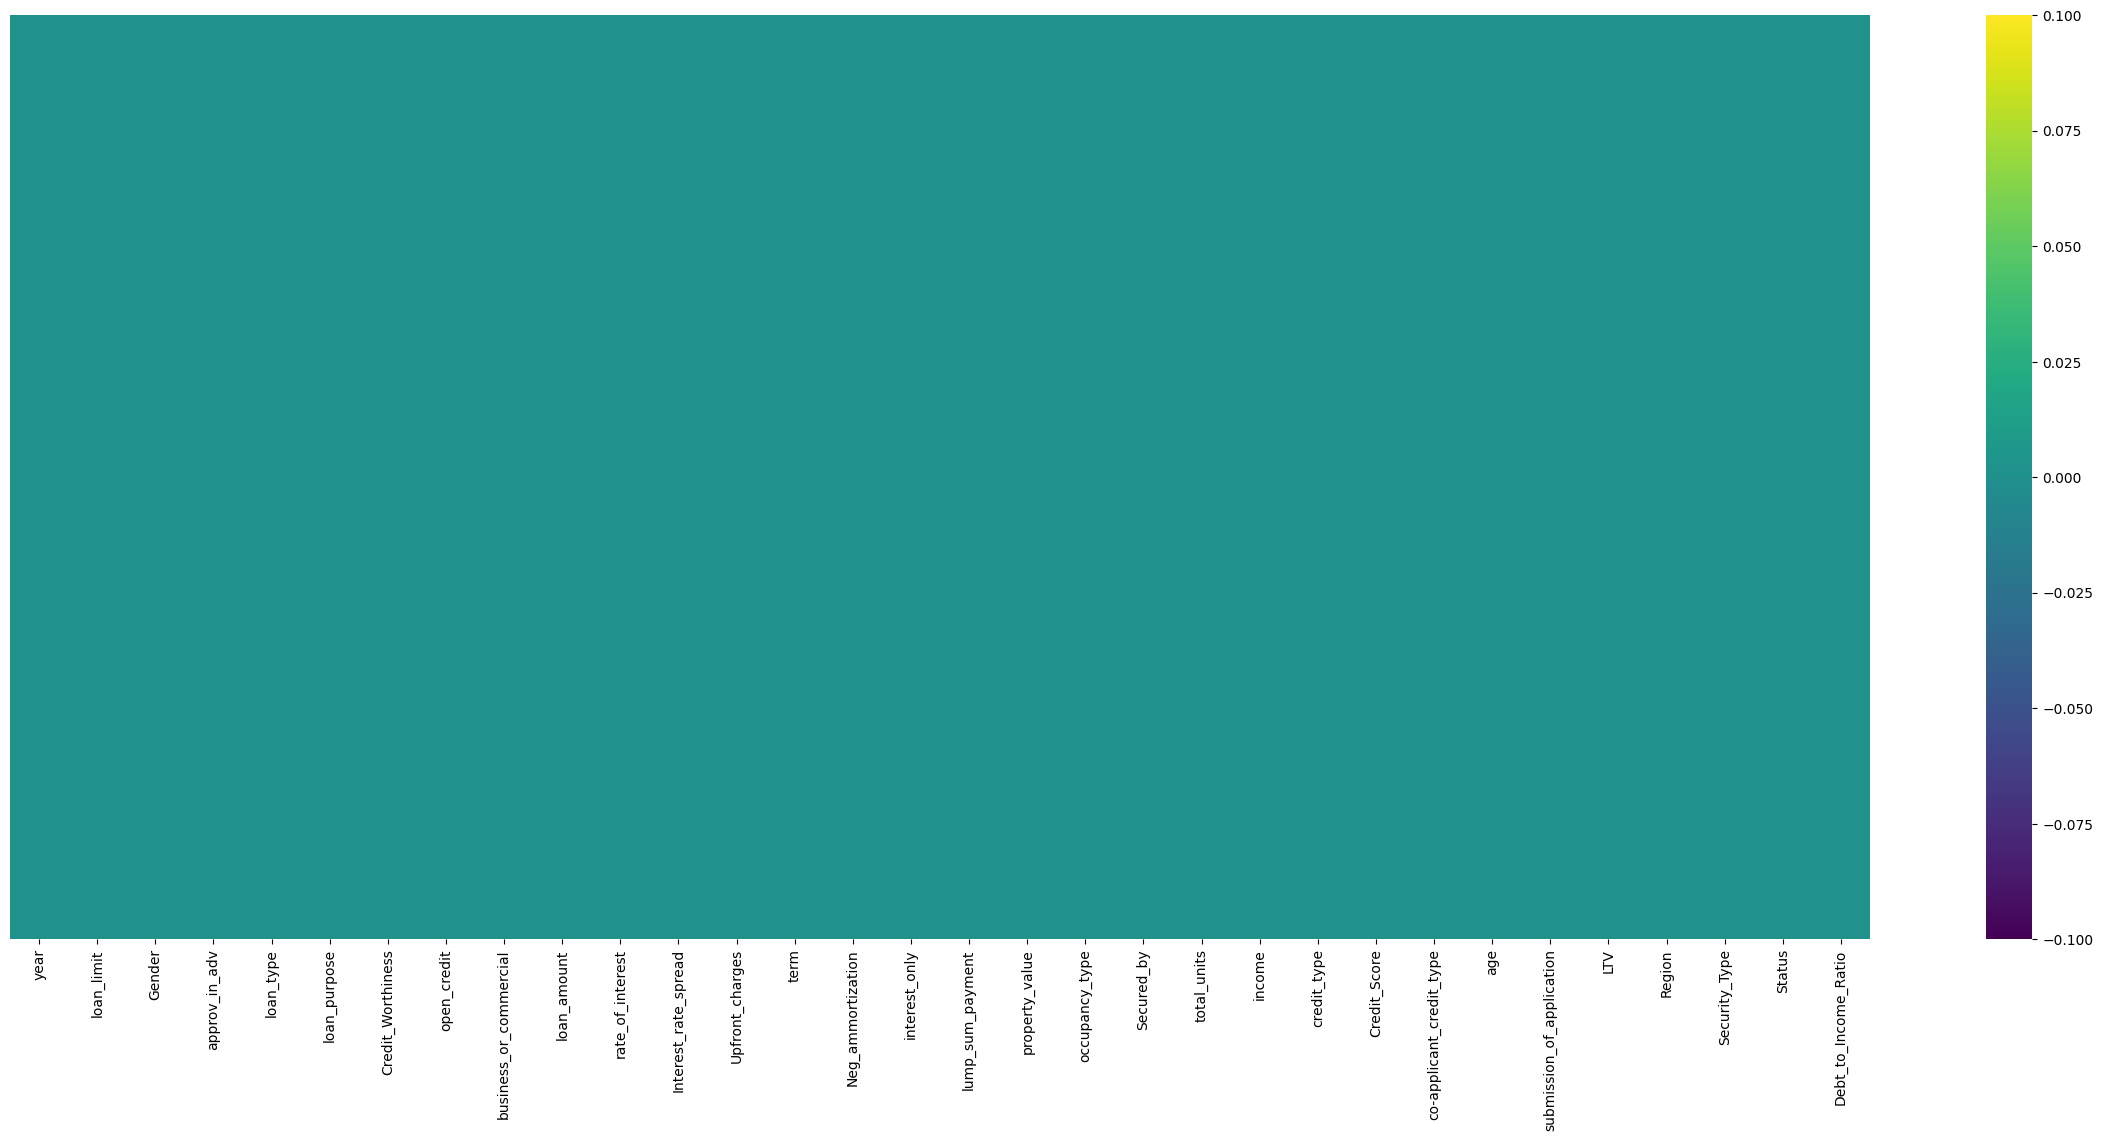

In [17]:
sorted=df.sort_values(by=["rate_of_interest","Interest_rate_spread","Upfront_charges"],ascending=False)

plt.figure(figsize=(30,12))
sns.heatmap(sorted.isnull(),yticklabels=False,cmap='viridis')
plt.show()

## Regression Time

In [18]:
X = df.drop(columns="Debt_to_Income_Ratio")
y = df["Debt_to_Income_Ratio"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (for KNN + Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## KNN

In [19]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_predictions = knn_model.predict(X_test_scaled)

KNN RMSE score

In [20]:
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_predictions))
print("KNN RMSE:", knn_rmse)

KNN RMSE: 10.517112468446268


## Decision Tree Regressor

In [34]:
tree_model = DecisionTreeRegressor(random_state=42)#,max_depth=5, min_samples_split=10,min_samples_leaf=5)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

Decision Tree Regressor RMSE score

In [35]:
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))
print("Decision Tree RMSE:", tree_rmse)


Decision Tree RMSE: 12.427168161439223


## Linear Regression

In [23]:
# Linear Regression Model
linreg_model = LinearRegression()
linreg_model.fit(X_train_scaled, y_train)

linreg_predictions = linreg_model.predict(X_test_scaled)


Linear Regression RSME score

In [24]:
# Linear Regression R² Score
linreg_rmse = np.sqrt(mean_squared_error(y_test, linreg_predictions))
print("Linear Regression RMSE:", linreg_rmse)


Linear Regression RMSE: 9.752607274453531


In [29]:
comparison = pd.DataFrame({
    "Model": ["KNN Regressor", "Decision Tree Regressor", "Linear Regression"],
    "RMSE Score": [knn_rmse, tree_rmse, linreg_rmse]
})

comparison.sort_values(by="RMSE Score", ascending=False)


,Model,RMSE Score
0,KNN Regressor,10.517112
2,Linear Regression,9.752607
1,Decision Tree Regressor,9.373987
